In [4]:
import pandas as pd
import numpy as np
import sklearn.model_selection as train_test_split
from openpyxl import load_workbook
from pathlib import Path
import io
import matplotlib
import seaborn as sns   
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
import sklearn.svm as svm
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler   
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression 
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [5]:

class info_modulo():
    def __init__(self, data):
        # inicialización
        self.data = data

    # Crear un dataframe para la df.info()
    def frame_info(self, data):
        buf = io.StringIO()
        data.info(buf=buf)
        s = buf.getvalue()
        lines = [line.split() for line in s.splitlines()[3:-2]]
        return pd.DataFrame(lines)

    def variables_null(self):
        null_columns = self.data.columns[self.data.isnull().any()]
        df_2 = pd.DataFrame(columns=['Nombre Variable', 'Cantidad de Nulos'])
        for col in null_columns:
            nueva_fila = {
                'Nombre Variable': col,
                'Cantidad de Nulos': self.data[col].isnull().sum()
            }
            df_2 = pd.concat([df_2, pd.DataFrame([nueva_fila])], ignore_index=True)
        return df_2

    def variables_nan(self):
        obj_df = self.data.select_dtypes(include=['object'])
        nan_columns = [col for col in obj_df.columns if obj_df[col].isnull().any() or (obj_df[col] == '').any()]
        df_2 = pd.DataFrame(columns=['Nombre Variable', 'Cantidad de Nan o vacíos'])
        for col in nan_columns:
            cantidad = obj_df[col].isnull().sum() + (obj_df[col] == '').sum()
            nueva_fila = {
                'Nombre Variable': col,
                'Cantidad de Nan o vacíos': cantidad
            }
            df_2 = pd.concat([df_2, pd.DataFrame([nueva_fila])], ignore_index=True)
        return df_2

    def info_dataframe(self, ruta = ''):
        print(f"Tamaño: {self.data.shape}")
        print("\n")
        print(f"Variables nulos: ")
        print(self.variables_null())
        print("\n")
        print(f"Variables NAN: ")
        print(self.variables_nan())
        print("\n")    
        print(f"Informacion dataframe: ")
        print(self.data.info())
        print("\n")
        print(f"Datos: ")
        print(self.data.head(10))
        print("\n")
        

In [6]:
df = pd.read_csv('members.csv')
df.head()

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_11092\2553658639.py:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('members.csv')


,expid,membid,peakid,myear,mseason,fname,lname,sex,yob,citizen,...,death,deathdate,deathtime,deathtype,deathhgtm,deathclass,msmtbid,msmtterm,hcn,mchksum
0,AMAD01101,2,AMAD,2001,Spring,Rohan,Buckley,M,1972.0,Australia,...,False,NaN,NaN,NaN,0,NaN,No summit bid,Did not climb or intent to summit,NaN,2439554
1,AMAD01101,1,AMAD,2001,Spring,Marc Cameron,Fairhead,M,1968.0,Australia,...,False,NaN,NaN,NaN,0,NaN,Aborted at high camp,"Bad conditions (deep snow, avalanches, falling...",NaN,2438062
2,AMAD01101,3,AMAD,2001,Spring,Mark,Schroeder,M,1960.0,Australia,...,False,NaN,NaN,NaN,0,NaN,Aborted at high camp,"Bad conditions (deep snow, avalanches, falling...",NaN,2435183
3,AMAD01101,4,AMAD,2001,Spring,Colin,Smith,M,1966.0,Australia,...,False,NaN,NaN,NaN,0,NaN,No summit bid,Did not climb or intent to summit,NaN,2437475
4,AMAD01101,5,AMAD,2001,Spring,Naomi,Smith,F,1970.0,Australia,...,False,NaN,NaN,NaN,0,NaN,No summit bid,Did not climb or intent to summit,NaN,2438996


In [7]:
df.infomodulo = info_modulo(df)
df.infomodulo.info_dataframe()

Tamaño: (89000, 61)


Variables nulos: 
   Nombre Variable Cantidad de Nulos
0            fname               103
1            lname              1124
2              yob              5408
3          citizen                 7
4        residence              8830
5       occupation             30739
6       mperhighpt             24946
7        msmtdate1             29269
8        msmtdate2             88551
9        msmtdate3             88978
10       msmttime1             62488
11       msmttime2             88756
12       msmttime3             88993
13         mo2note             73653
14       deathdate             87868
15       deathtime             88432
16       deathtype             87842
17      deathclass             87842
18        msmtterm               176
19             hcn             88705


Variables NAN: 
   Nombre Variable Cantidad de Nan o vacíos
0            fname                      103
1            lname                     1124
2          citizen               

In [8]:
df_copy = df.copy()

In [9]:
df_copy['edad']=df_copy['myear'] - df_copy['yob']

In [10]:

def rellenar_yob_por_edad_promedio_aleatoria(df, yob_col='yob', myear_col='myear', rango=5, random_state=None):
    """
    Rellena los valores faltantes en 'yob' estimando la edad como un valor aleatorio
    dentro del rango edad_promedio ± rango, y restándolo al año de registro.

    Parámetros:
    - df: DataFrame original
    - yob_col: nombre de la columna con el año de nacimiento
    - myear_col: nombre de la columna con el año de registro
    - rango: margen aleatorio alrededor de la edad promedio (por defecto ±5 años)
    - random_state: semilla para reproducibilidad (opcional)

    Devuelve:
    - DataFrame con 'yob' rellenado de manera realista
    """
    df = df.copy()
    rng = np.random.default_rng(seed=random_state)

    # Calcular edad promedio solo con valores razonables
    edades_validas = (df[myear_col] - df[yob_col]).dropna()
    edades_validas = edades_validas[(edades_validas >= 13) & (edades_validas <= 80)]
    edad_promedio = edades_validas.mean().round()

    # Identificar posiciones a rellenar
    mask = df[yob_col].isnull() & df[myear_col].notnull()


    # Generar edades aleatorias en el rango permitido
    cantidad = mask.sum()
    edades_estimadas = rng.integers(edad_promedio - rango, edad_promedio + rango + 1, size=cantidad)

    # Asignar yob = myear - edad aleatoria
    df.loc[mask, yob_col] = df.loc[mask, myear_col].values - edades_estimadas

    return df



In [ ]:
df_copy = rellenar_yob_por_edad_promedio_aleatoria(df_copy, yob_col='yob', myear_col='myear', random_state=42)

# Crear una máscara para edades inválidas
edad_invalida = (df_copy['edad'] < 13) | (df_copy['edad'] > 80)

# Guardar estos registros aparte
df_edad_fuera_rango = df_copy[edad_invalida].copy()

# Eliminar estos registros del DataFrame original
df_copy = df_copy[~edad_invalida].copy()



In [ ]:
# Definir los bins de edad (por ejemplo, cada 5 años)
bins = list(range(int(df_copy['edad'].min()), int(df_copy['edad'].max()) + 5, 5))
labels = [f"{b}-{b+4}" for b in bins[:-1]]
# Crear una nueva columna de rango de edad
df_copy['edad_rango'] = pd.cut(df_copy['edad'], bins=bins, labels=labels, right=False)
orden = {'13-17': 1, '18-22': 2, '23-27': 3, '28-32': 4, '33-37': 5, '38-42': 6, '43-47': 7,'48-52': 8, '53-57': 9, '58-62': 10, '63-67': 11, '68-72': 12, '73-77': 13, '78-82': 14}
df_copy['rango_edad_ordinal'] = df_copy['edad_rango'].map(orden)
df_copy['rango_edad_ordinal'] = df_copy['rango_edad_ordinal'].astype(int)
df_copy = df_copy.drop(columns=['edad_rango'])  # usa el nombre exacto de la columna

In [12]:
def imputar_o_eliminar_nulos(df, target_column='death', porcnull_aceptable=30, metodo='METKNN'):
    columnas_eliminadas = []
    columnas_imputadas = {}

    # Procesar columnas tipo object (textuales) antes de rellenar
    for col in df.select_dtypes(include='object').columns:
        porcentaje = 100 * df[col].isnull().sum() / df.shape[0]
        if porcentaje >= porcnull_aceptable:
            df.drop(col, axis=1, inplace=True)
            columnas_eliminadas.append(col)
        else:
            df[col] = df[col].astype(str).fillna('no information')
            columnas_imputadas[col] = 'no information'

    # Ahora procesar columnas numéricas con nulos
    columnas_numericas = df.select_dtypes(include=['number']).drop(columns=[target_column], errors='ignore')
    columnas_con_nulos = columnas_numericas.columns[columnas_numericas.isnull().any()]

    for col in columnas_con_nulos:
        porcentaje = 100 * df[col].isnull().sum() / df.shape[0]
        if porcentaje >= porcnull_aceptable:
            df.drop(col, axis=1, inplace=True)
            columnas_eliminadas.append(col)
        else:
            if metodo == 'METKNN':
                imputer = KNNImputer(n_neighbors=5)
                df[[col]] = imputer.fit_transform(df[[col]])
                columnas_imputadas[col] = 'KNN'
            elif metodo == 'METMEDIA':
                df[col] = SimpleImputer(strategy='mean').fit_transform(df[[col]])
                columnas_imputadas[col] = 'Media'
            elif metodo == 'METMODA':
                df[col] = SimpleImputer(strategy='most_frequent').fit_transform(df[[col]])
                columnas_imputadas[col] = 'Moda'
            else:
                df.dropna(subset=[col], inplace=True)
                columnas_eliminadas.append(col)

    print("Columnas eliminadas:", columnas_eliminadas)
    print("Columnas imputadas:", columnas_imputadas)
    return df



In [13]:
imputar_o_eliminar_nulos(df_copy, porcnull_aceptable=30, metodo='METKNN')
df_copy.infodf = info_modulo(df_copy)

Columnas eliminadas: ['occupation', 'msmtdate1', 'msmtdate2', 'msmtdate3', 'mo2note', 'deathdate', 'deathtype', 'deathclass', 'msmttime1', 'msmttime2', 'msmttime3', 'deathtime', 'hcn']
Columnas imputadas: {'expid': 'no information', 'peakid': 'no information', 'mseason': 'no information', 'fname': 'no information', 'lname': 'no information', 'sex': 'no information', 'citizen': 'no information', 'status': 'no information', 'residence': 'no information', 'msmtbid': 'no information', 'msmtterm': 'no information', 'mperhighpt': 'KNN'}


In [14]:

def eliminar_alta_cardinalidad(df, target_column='death', umbral=2, excepciones=None):
    """
    Elimina columnas categóricas de alta cardinalidad del DataFrame.

    Parámetros:
    - df: DataFrame original.
    - target_column: columna objetivo a conservar.
    - umbral: porcentaje máximo de cardinalidad permitido.
    - excepciones: lista de columnas que no se deben eliminar.

    Devuelve:
    - df filtrado.
    - lista de columnas eliminadas.
    """
    if excepciones is None:
        excepciones = []

    columnas_eliminadas = []

    columnas_cat = df.drop(columns=[target_column], errors='ignore')\
                     .select_dtypes(include=['object', 'category']).columns

    cardinalidad = df[columnas_cat].nunique() * 100 / df.shape[0]

    cols = [col for col in cardinalidad[cardinalidad > umbral].index if col not in excepciones]

    for col in cols:
        print(f"🗑️ Eliminando '{col}' con {df[col].nunique()} categorías únicas ({cardinalidad[col]:.2f}%)")
        df.drop(columns=col, inplace=True)
        columnas_eliminadas.append(col)

    return df, columnas_eliminadas




In [15]:
eliminar_alta_cardinalidad(df_copy, target_column='death', umbral=0.8, excepciones=['mseason', 'msuccess'])

🗑️ Eliminando 'expid' con 11315 categorías únicas (13.09%)
🗑️ Eliminando 'fname' con 20699 categorías únicas (23.94%)
🗑️ Eliminando 'lname' con 24524 categorías únicas (28.36%)
🗑️ Eliminando 'residence' con 14767 categorías únicas (17.08%)


(       membid peakid  myear mseason sex     yob      citizen      status  \
 0           2   AMAD   2001  Spring   M  1972.0    Australia     Climber   
 1           1   AMAD   2001  Spring   M  1968.0    Australia      Leader   
 2           3   AMAD   2001  Spring   M  1960.0    Australia     Climber   
 3           4   AMAD   2001  Spring   M  1966.0    Australia     Climber   
 4           5   AMAD   2001  Spring   F  1970.0    Australia     Climber   
 ...       ...    ...    ...     ...  ..     ...          ...         ...   
 88981       4   GIMM   1920  Summer   M  1886.0        Nepal  H-A Worker   
 88982       1   LNPS   1920  Summer   M  1893.0  Switzerland      Leader   
 88990       9   LNPS   1907  Summer   M  1869.0        Nepal  H-A Worker   
 88996       3   SURM   1905  Spring   M  1863.0           UK  Exp Doctor   
 88998       5   SURM   1905  Spring   M  1863.0           UK     Climber   
 
        leader  deputy  ...  mo2climb  mo2descent  mo2sleep  mo2medical  d

In [16]:
df_copy = df_copy.drop(['citizen', 'peakid', 'status'], axis=1)

In [17]:
def eliminar_correlacionadas(df, target_column=None, umbral=0.75):
    """
    Convierte columnas bool y object a numéricas y elimina columnas altamente correlacionadas.
    """
    df = df.copy()

    # 1. Convertir columnas booleanas a enteros
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    # 2. One-hot encoding para columnas object
    obj_cols = df.select_dtypes(include='object').columns
    df = pd.get_dummies(df, columns=obj_cols, drop_first=True)

    # 3. Eliminar columnas objetivo si están especificadas
    if target_column is not None:
        if isinstance(target_column, str):
            drop_cols = [target_column]
        else:
            drop_cols = list(target_column)
        num_df = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
    else:
        num_df = df.select_dtypes(include=[np.number])

    # 4. Calcular matriz de correlación
    corr = num_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    # 5. Identificar columnas a eliminar
    to_drop = [col for col in upper.columns if any(upper[col] > umbral)]

    # 6. Eliminar columnas del DataFrame original (no del que se codificó)
    df_final = df.drop(columns=to_drop)

    print(f"Columnas eliminadas por alta correlación: {to_drop}")
    return df_final, to_drop


In [18]:
df_copy, columnas_eliminadas = eliminar_correlacionadas(df_copy, target_column=['death', 'msmtbid_Successful summit bid'], umbral=0.75)


Columnas eliminadas por alta correlación: ['yob', 'sherpa', 'mhighpt', 'mo2none', 'mo2climb']


In [30]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay


In [20]:
class modelo_ml_binario:
    def __init__(self, x, y):
        self.x = x.copy()
        self.y = y.copy()
        self.X_test = None  # Inicializar atributo
        self.y_test = None  # Inicializar atributo

    def division_datos(self, tamano, seed_number, estratificar='NO'):
        if estratificar.upper() == 'SI':
            X_train, X_test, y_train, y_test = train_test_split(
                self.x, self.y, test_size=tamano, random_state=seed_number, stratify=self.y)
        else:
            X_train, X_test, y_train, y_test = train_test_split(
                self.x, self.y, test_size=tamano, random_state=seed_number)
        
        # Guardar los datos de prueba como atributos
        self.X_test = X_test
        self.y_test = y_test
        
        return X_train, X_test, y_train, y_test

    def entrenar(self, modelo, seed_number=42, tamano=0.2, escalar='NO', escala_func=None,
                 estimador='accuracy', tipo='CLASIFICACION', estratificar='SI'):
        X_train, X_test, y_train, y_test = self.division_datos(tamano, seed_number, estratificar)
        
        # Renombrar columnas antes de escalar
        X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
        X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

        if escalar.upper() == 'SI' and escala_func is not None:
            X_train = escala_func.fit_transform(X_train)
            X_test = escala_func.transform(X_test)

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_pred_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else None

        if estimador == 'accuracy':
            train_score = modelo.score(X_train, y_train)
            test_score = accuracy_score(y_test, y_pred)
        elif estimador == 'recall':
            test_score = recall_score(y_test, y_pred)
            train_score = None
        elif estimador == 'f1_score':
            test_score = f1_score(y_test, y_pred)
            train_score = None
        elif estimador == 'roc' and y_pred_proba is not None:
            test_score = roc_auc_score(y_test, y_pred_proba)
            train_score = None
        else:
            test_score = None
            train_score = None

        return {
            'modelo': modelo,
            'X_test': X_test,  # Añadimos X_test al diccionario de retorno
            'y_test': y_test,  # Añadimos y_test al diccionario de retorno
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'accuracy': test_score if estimador == 'accuracy' else None,
            'recall': recall_score(y_test, y_pred) if estimador in ['accuracy','recall','f1_score'] else None,
            'f1': f1_score(y_test, y_pred) if estimador in ['accuracy','recall','f1_score'] else None,
            'roc_auc': roc_auc_score(y_test, y_pred_proba) if estimador=='roc' else None
        }

In [26]:
def filtrar_columnas(df, target):
    columnas_a_excluir = [
        'msuccess', 'death', 'mclaimed', 'mdisputed', 'mperhighpt',
        'mo2used', 'mo2descent', 'mo2sleep', 'mo2medical',
    ]
    
    columnas_msmtterm = [col for col in df.columns if col.startswith('msmtterm_')]
    columnas_msmtbid = [col for col in df.columns if col.startswith('msmtbid_')]
    
    # Evitar quitar el target que estés usando
    columnas_a_excluir = [col for col in columnas_a_excluir if col != target]
    
    columnas_a_excluir += [col for col in columnas_msmtterm if col != target]
    columnas_a_excluir += [col for col in columnas_msmtbid if col != target]

    X = df.drop(columns=columnas_a_excluir + [target])
    y = df[target]
    return X, y


In [27]:
X, y_success = filtrar_columnas(df_copy, 'msmtbid_Successful summit bid')
X, y_death = filtrar_columnas(df_copy, 'death')

m_death = modelo_ml_binario(X, y_death)
m_success = modelo_ml_binario(X, y_success)

# Definir modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

modelos = {
    'RF': RandomForestClassifier(
    n_estimators=200,             # número de árboles
    max_depth=15,                 # profundidad máxima del árbol
    min_samples_split=10,         # mínimo de muestras para dividir un nodo
    min_samples_leaf=5,           # mínimo de muestras en una hoja
    max_features='sqrt',          # número de features a considerar por división
    class_weight='balanced',      # muy importante para desbalance
    random_state=42,
    n_jobs=-1                     # usar todos los núcleos disponibles
),
    'LR': LogisticRegression(
    penalty='l2',                 # regularización ridge
    C=1.0,                        # inverso de la fuerza de regularización
    solver='lbfgs',              # bueno para datasets pequeños-medianos
    max_iter=2000,               # más iteraciones para converger
    class_weight='balanced',     # ajusta pesos automáticamente según clases
    random_state=42
),
    'XGB': XGBClassifier(objective='binary:logistic',
    eval_metric='auc',
    #use_label_encoder=False,     # para evitar warnings
    scale_pos_weight=75,         # proporción de negativos/positivos ≈ 68264/906
    learning_rate=0.05,
    n_estimators=200,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1),
    
'LGBM': LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='auc',
    is_unbalance=True,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_data_in_leaf=20,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    verbose=-1,
    n_estimators=200,
    force_col_wise=True  # útil si hay problemas de memoria
)
}

resultados = {}
for name, model in modelos.items():
    # Para death
    res_death = m_death.entrenar(modelo=model, estimador='accuracy')
    # Para success
    res_success = m_success.entrenar(modelo=model, estimador='accuracy')
    
    # Guardar también los datos de prueba
    resultados[name] = {
        'death': {
            'modelo': res_death['modelo'],
            'X_test': m_death.X_test,  # Añadir X_test
            'y_test': m_death.y_test   # Añadir y_test
        },
        'msmtbid_Successful summit bid': {
            'modelo': res_success['modelo'],
            'X_test': m_success.X_test,  # Añadir X_test
            'y_test': m_success.y_test   # Añadir y_test
        }
    }

In [41]:
# Crear DataFrame de resultados
metricas = ['accuracy', 'recall', 'f1', 'roc_auc']
resumen = []

for modelo, resultados_modelo in resultados.items():
    fila = {'modelo': modelo}
    for target in ['death', 'msmtbid_Successful summit bid']:
        for metrica in metricas:
            key = f'{target}_{metrica}'
            fila[key] = resultados_modelo[target].get(metrica)
    resumen.append(fila)

df_resultados = pd.DataFrame(resumen)
df_resultados = df_resultados.applymap(lambda x: np.nan if x is None else x)
pd.set_option('display.float_format', '{:.3f}'.format)
display(df_resultados)

C:\Users\Fabrizio\AppData\Local\Temp\ipykernel_11092\1266217755.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_resultados = df_resultados.applymap(lambda x: np.nan if x is None else x)


,modelo,death_accuracy,death_recall,death_f1,death_roc_auc,msmtbid_Successful summit bid_accuracy,msmtbid_Successful summit bid_recall,msmtbid_Successful summit bid_f1,msmtbid_Successful summit bid_roc_auc
0,RF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,XGB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LGBM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
from sklearn.metrics import balanced_accuracy_score, precision_recall_curve, average_precision_score

In [33]:
X_train, X_test, y_train, y_test = m_success.division_datos(tamano=0.2, seed_number=42, estratificar='SI')

# Usar el modelo entrenado correspondiente
model = resultados['LGBM']['msmtbid_Successful summit bid']['modelo']

# Renombrar columnas de X_test igual que en el entrenamiento
X_test = X_test.copy()
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # para la clase positiva

bal_acc = balanced_accuracy_score(y_test, y_pred)
avg_prec = average_precision_score(y_test, y_proba)

prec, rec, thresholds = precision_recall_curve(y_test, y_proba)



=== Análisis para death ===


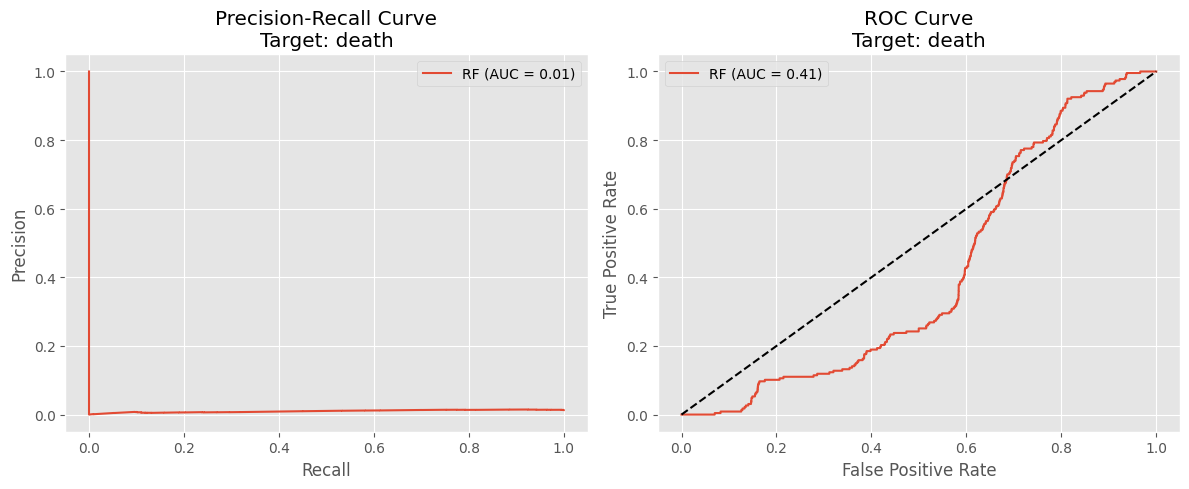

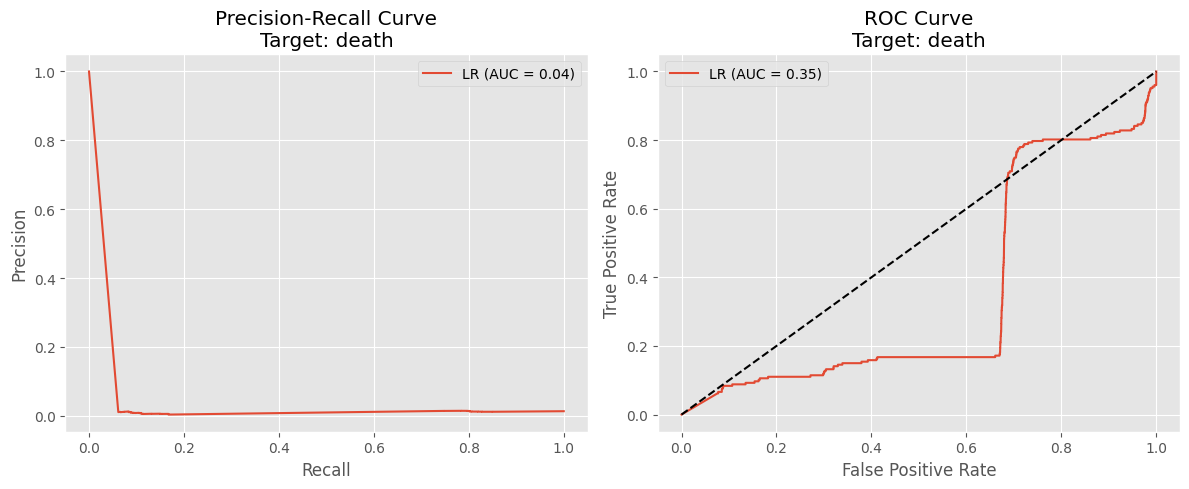

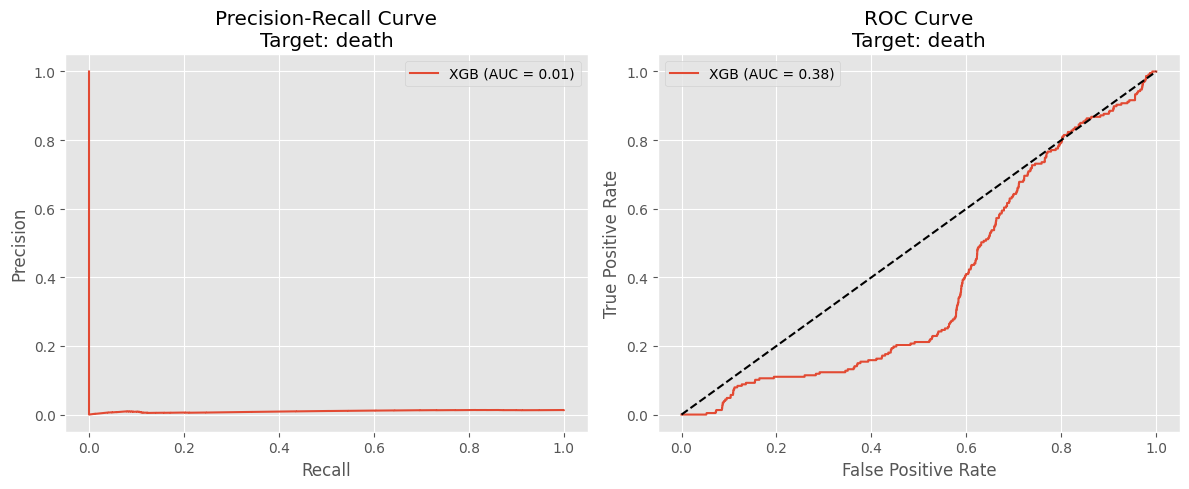

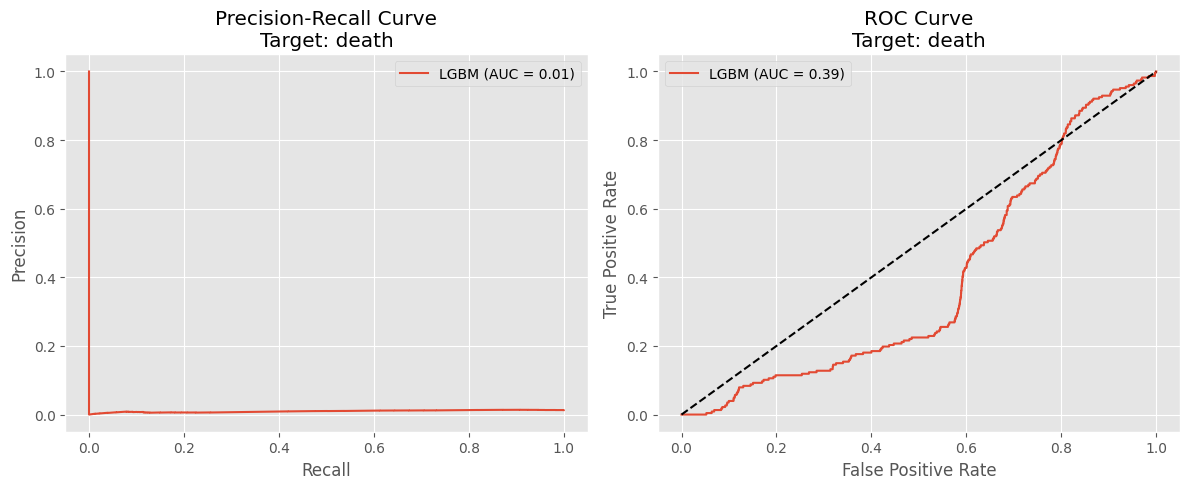


=== Análisis para msmtbid_Successful summit bid ===


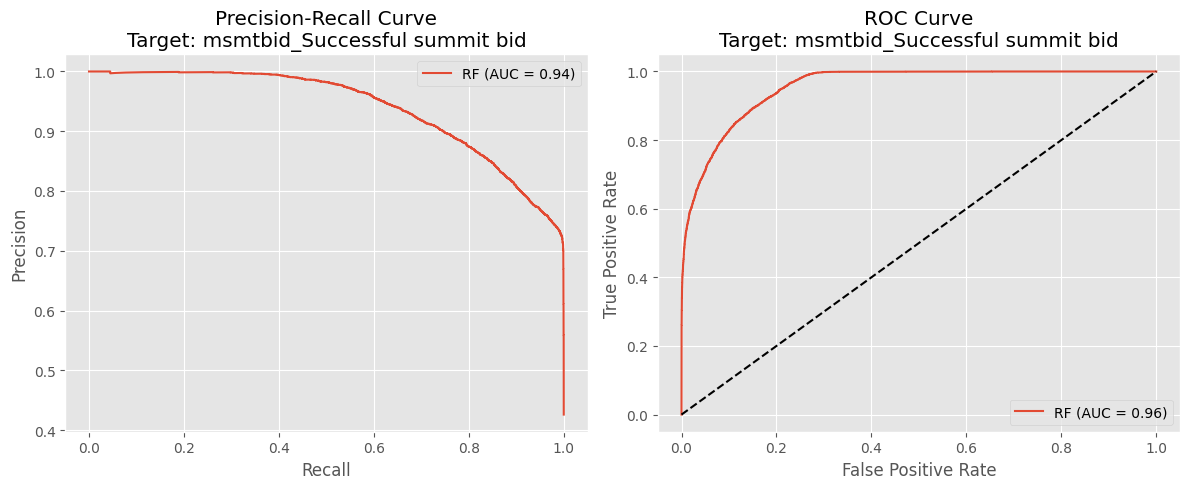

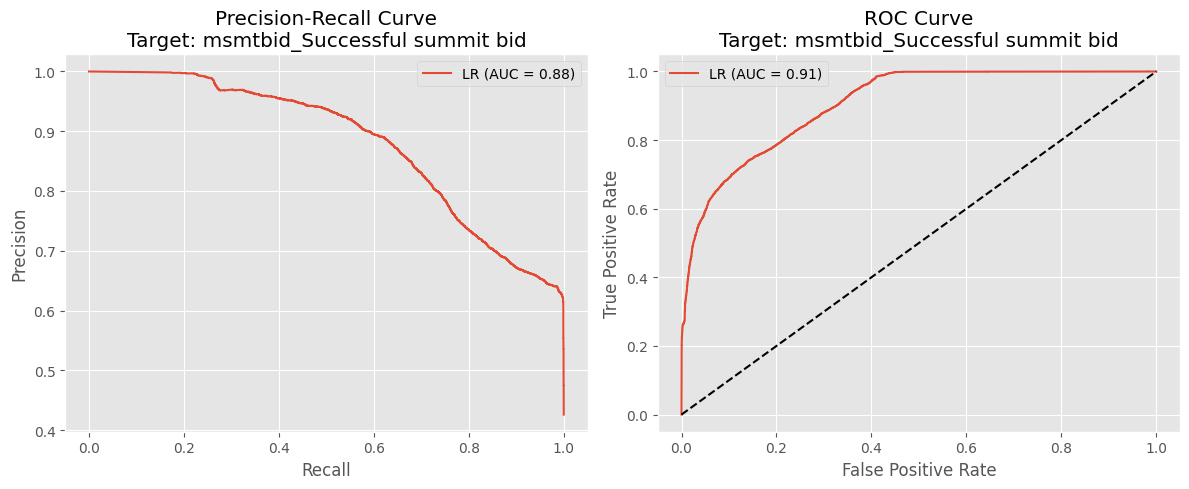

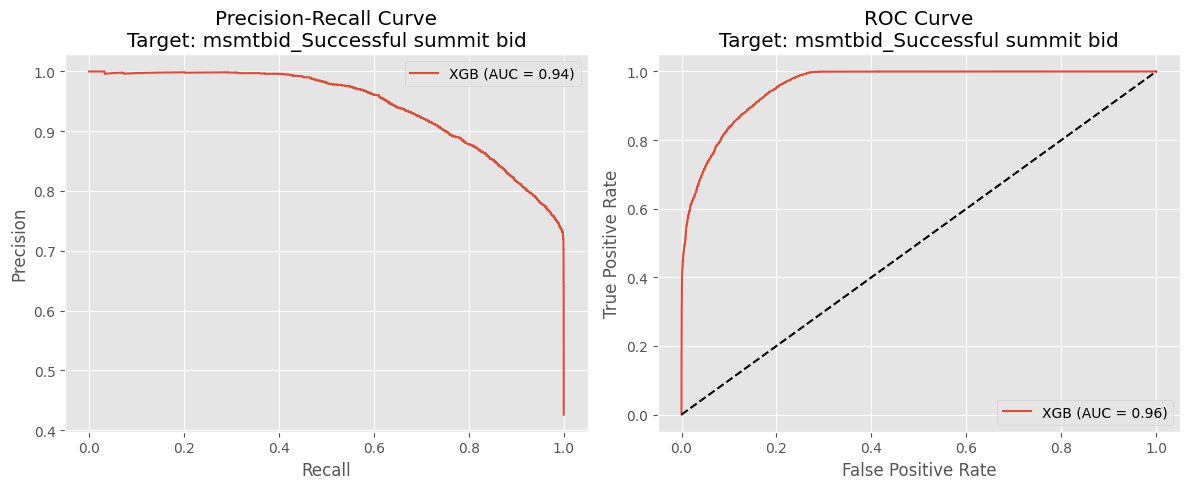

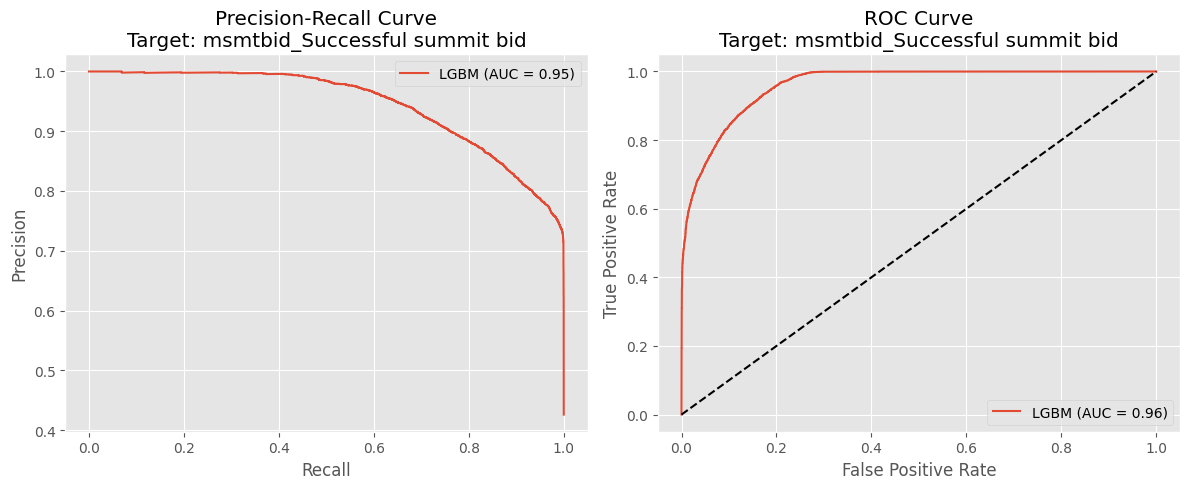

In [42]:
from sklearn.metrics import auc, roc_curve

def plot_metrics(y_true, y_proba, model_name, target):
    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot both curves
    plt.figure(figsize=(12, 5))
    
    # Precision-Recall
    plt.subplot(1, 2, 1)
    plt.plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve\nTarget: {target}')
    plt.legend()
    
    # ROC
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve\nTarget: {target}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Evaluar todos los modelos para ambas variables objetivo
for target in ['death', 'msmtbid_Successful summit bid']:
    print(f"\n=== Análisis para {target} ===")
    for model_name in modelos.keys():
        model_info = resultados[model_name][target]
        model = model_info['modelo']
        X_test = model_info['X_test']
        y_test = model_info['y_test']
        
        # Asegurar que los nombres de columnas sean consistentes
        X_test = X_test.copy()
        X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
        
        y_proba = model.predict_proba(X_test)[:, 1]
        plot_metrics(y_test, y_proba, model_name, target)


=== Feature Importance para death ===

Modelo: RF


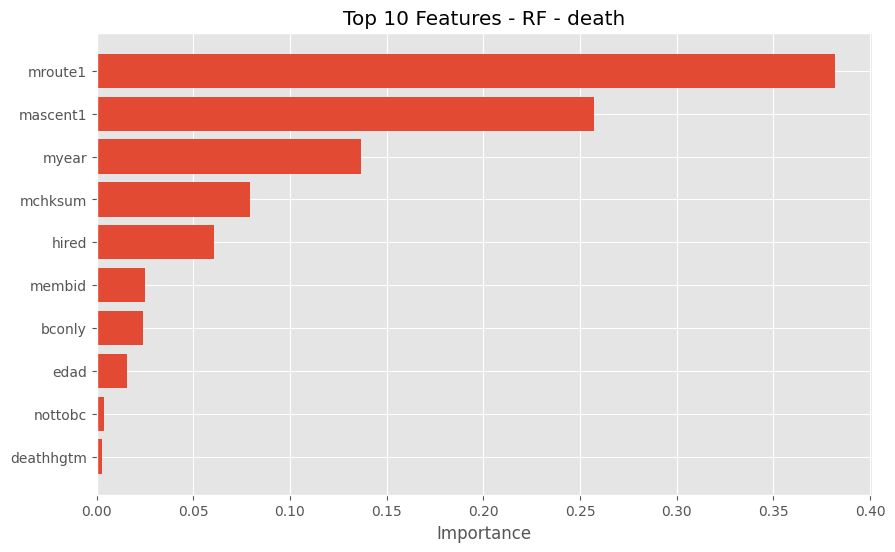

      feature  importance
15    mroute1       0.382
18   mascent1       0.257
1       myear       0.136
22    mchksum       0.080
8       hired       0.061
0      membid       0.025
4      bconly       0.024
23       edad       0.016
5     nottobc       0.004
21  deathhgtm       0.003

Modelo: LR


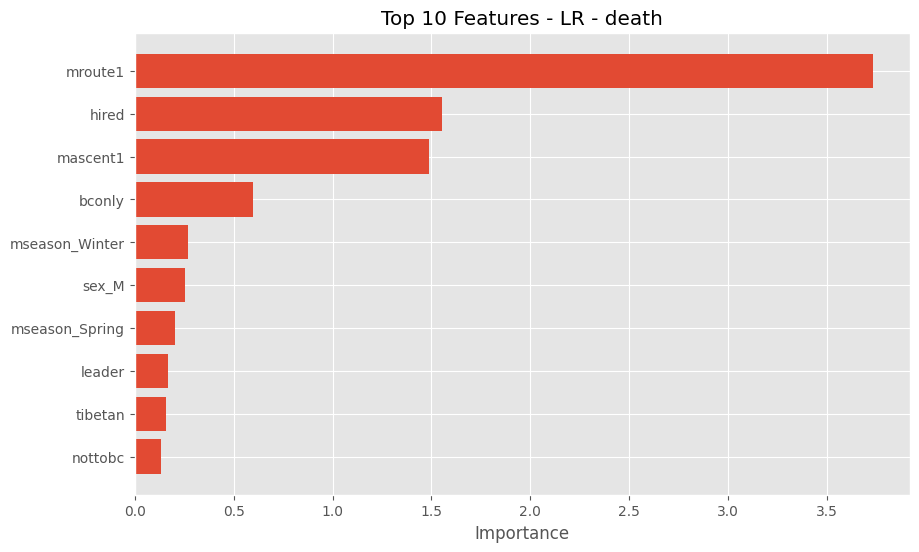

           feature  importance
15         mroute1       3.731
8            hired       1.552
18        mascent1       1.486
4           bconly       0.599
26  mseason_Winter       0.269
27           sex_M       0.255
24  mseason_Spring       0.202
2           leader       0.166
9          tibetan       0.160
5          nottobc       0.133

Modelo: XGB


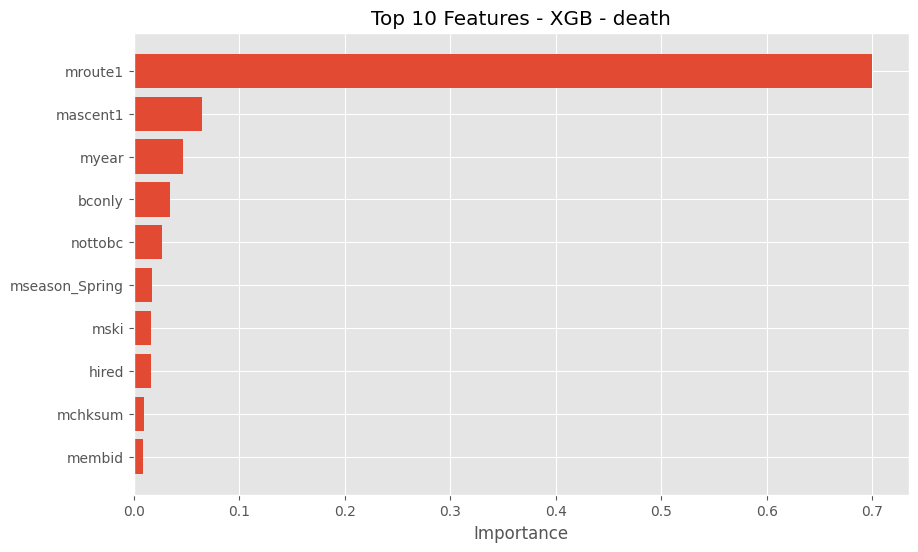

           feature  importance
15         mroute1       0.700
18        mascent1       0.065
1            myear       0.047
4           bconly       0.034
5          nottobc       0.027
24  mseason_Spring       0.017
12            mski       0.016
8            hired       0.016
22         mchksum       0.009
0           membid       0.009

Modelo: LGBM


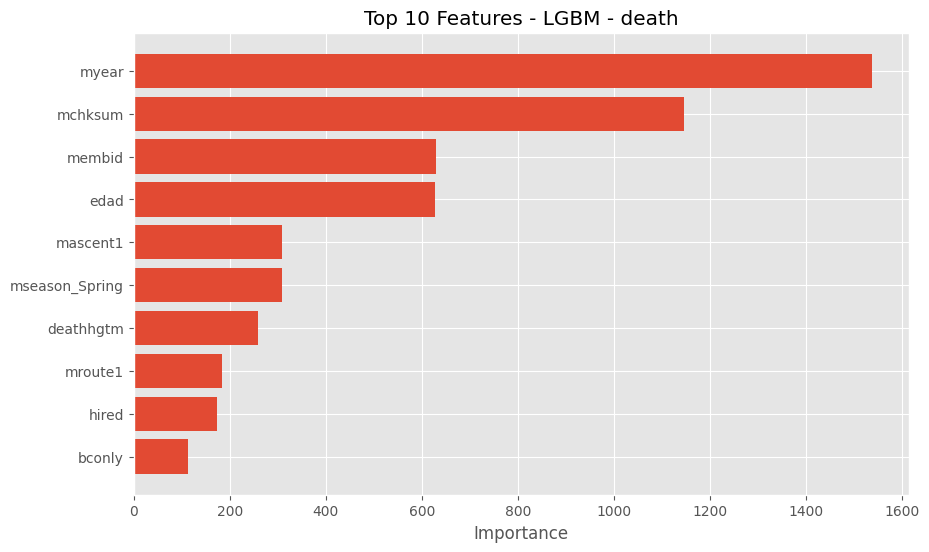

           feature  importance
1            myear        1537
22         mchksum        1146
0           membid         630
23            edad         628
18        mascent1         309
24  mseason_Spring         308
21       deathhgtm         259
15         mroute1         183
8            hired         173
4           bconly         112

=== Feature Importance para msmtbid_Successful summit bid ===

Modelo: RF


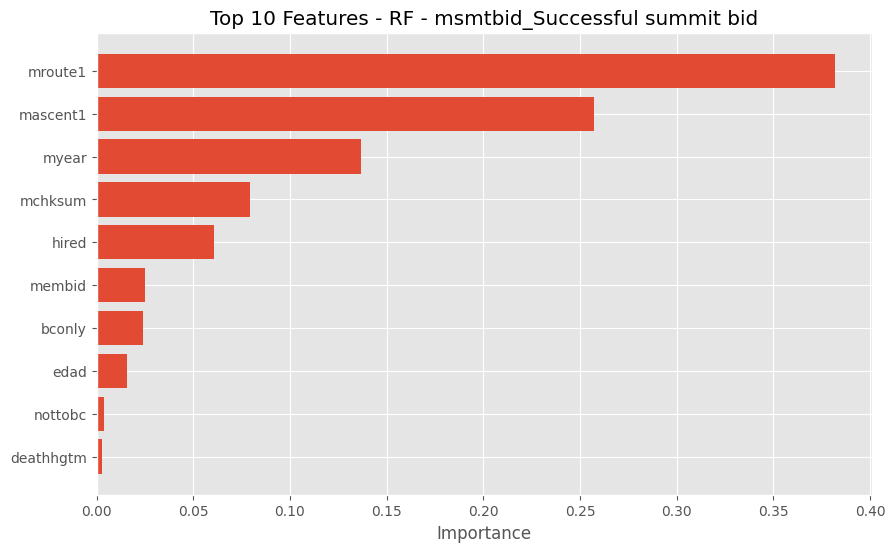

      feature  importance
15    mroute1       0.382
18   mascent1       0.257
1       myear       0.136
22    mchksum       0.080
8       hired       0.061
0      membid       0.025
4      bconly       0.024
23       edad       0.016
5     nottobc       0.004
21  deathhgtm       0.003

Modelo: LR


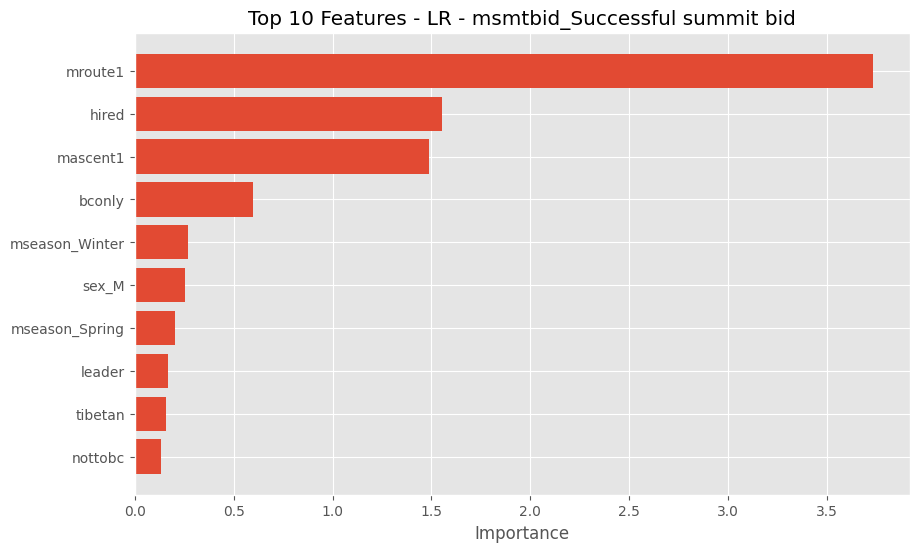

           feature  importance
15         mroute1       3.731
8            hired       1.552
18        mascent1       1.486
4           bconly       0.599
26  mseason_Winter       0.269
27           sex_M       0.255
24  mseason_Spring       0.202
2           leader       0.166
9          tibetan       0.160
5          nottobc       0.133

Modelo: XGB


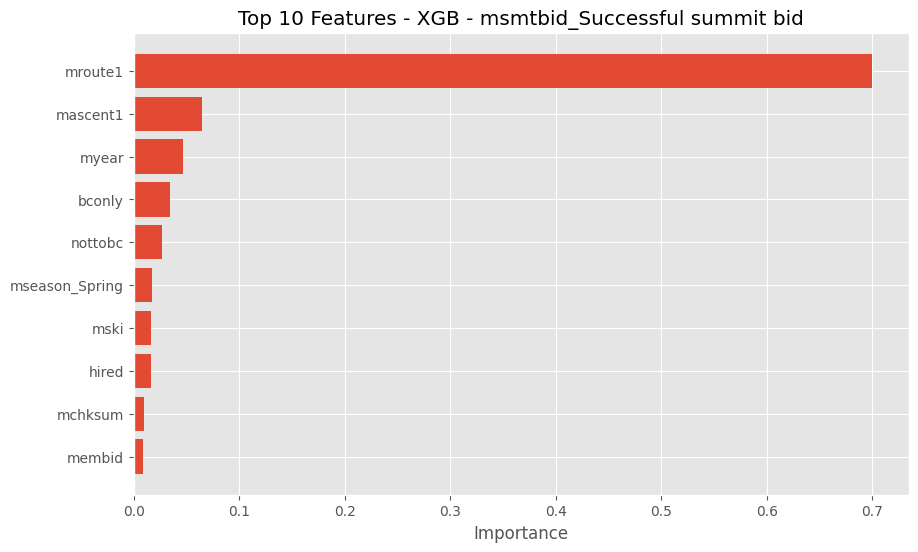

           feature  importance
15         mroute1       0.700
18        mascent1       0.065
1            myear       0.047
4           bconly       0.034
5          nottobc       0.027
24  mseason_Spring       0.017
12            mski       0.016
8            hired       0.016
22         mchksum       0.009
0           membid       0.009

Modelo: LGBM


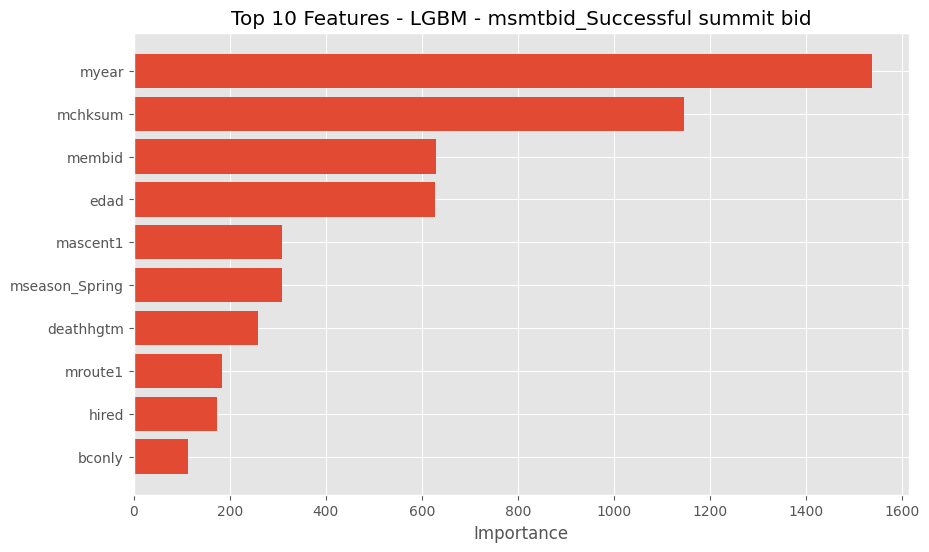

           feature  importance
1            myear        1537
22         mchksum        1146
0           membid         630
23            edad         628
18        mascent1         309
24  mseason_Spring         308
21       deathhgtm         259
15         mroute1         183
8            hired         173
4           bconly         112


In [39]:
def plot_feature_importance(model, feature_names, model_name, target, top_n=10):
    # Obtener importancias según el tipo de modelo
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        print(f"No se puede obtener feature importance para {model_name}")
        return
    
    # Crear DataFrame con las importancias
    feature_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(top_n)
    
    # Graficar
    plt.figure(figsize=(10, 6))
    plt.barh(feature_imp['feature'], feature_imp['importance'])
    plt.gca().invert_yaxis()
    plt.title(f'Top {top_n} Features - {model_name} - {target}')
    plt.xlabel('Importance')
    plt.show()
    
    return feature_imp

# Obtener nombres de características
feature_names = X.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

# Analizar feature importance para cada modelo y target
for target in ['death', 'msmtbid_Successful summit bid']:
    print(f"\n=== Feature Importance para {target} ===")
    for model_name in modelos.keys():
        model = resultados[model_name][target]['modelo']
        print(f"\nModelo: {model_name}")
        feature_imp = plot_feature_importance(model, feature_names, model_name, target)
        print(feature_imp)